# **Intestinal polyp segmentation using images extracted from colonoscopy video frames**

# **0. Dependencies**

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
import os

# **1. Preparing Data**

**Dataset Description (CVC-ClinicDB)**

CVC-ClinicDB is a public dataset consisting of frames extracted from colonoscopy videos. Each image contains one or more colorectal polyps, along with a corresponding binary mask that indicates the polyp region.
The dataset was generated from 25 different video studies and contains frames from 29 distinct polyp sequences, ensuring diversity in appearance, size, and viewpoint of polyps.

Each sample includes:

*   An RGB colonoscopy image
*   A ground-truth mask highlighting the polyp region



**Loading data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
image_dir = r"/content/drive/My Drive/Dataset/CVC-ClinicDB/Original"
mask_dir = r"/content/drive/My Drive/Dataset/CVC-ClinicDB/Ground Truth"

**Visualization of Image–Mask Pairs**

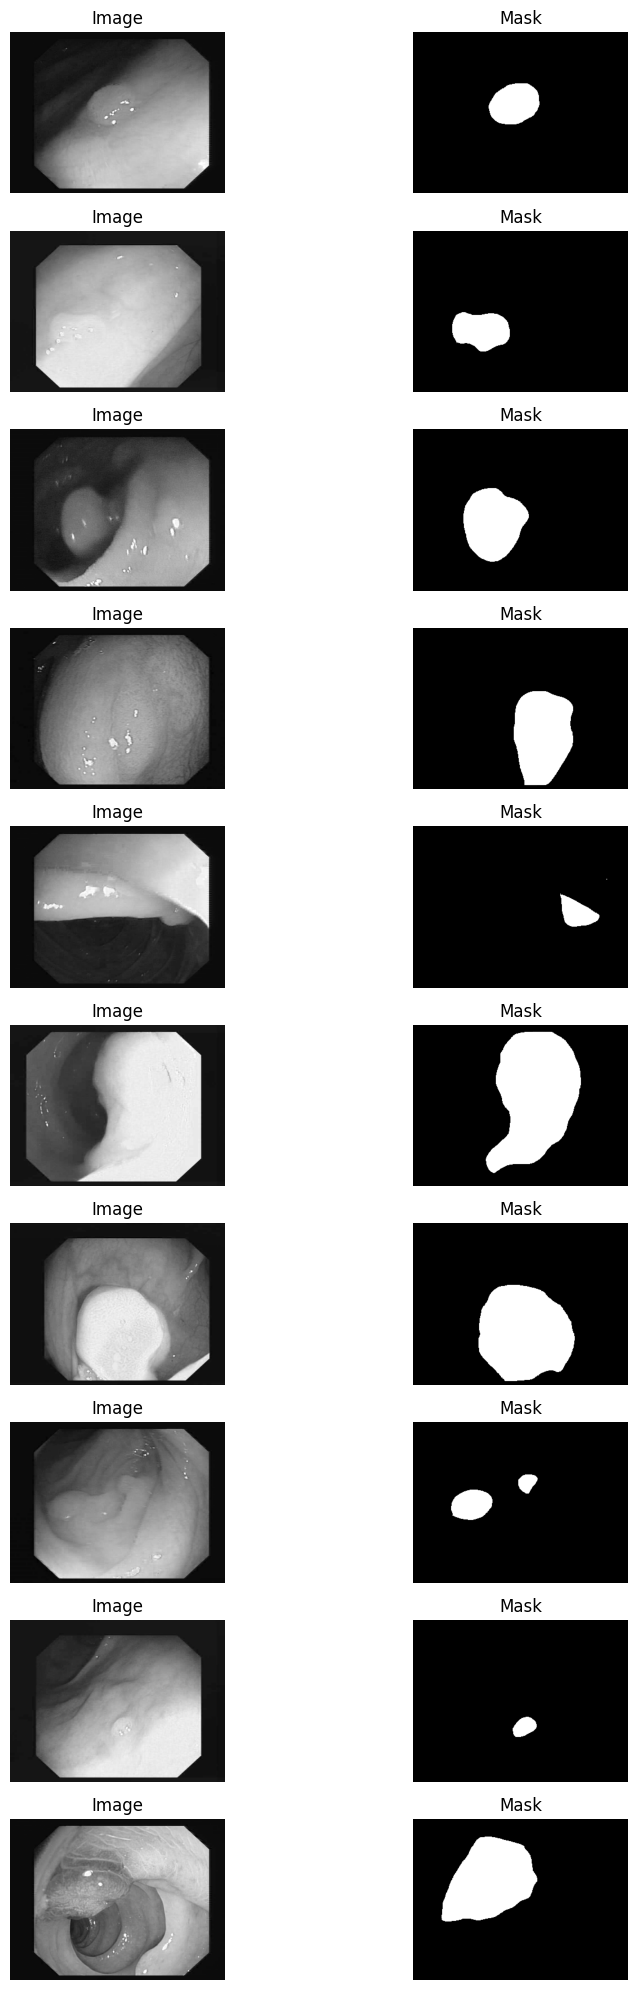

In [ ]:
image_names = sorted(os.listdir(image_dir))
sample_names = random.sample(image_names, 10)

plt.figure(figsize=(10, 20))

for i, name in enumerate(sample_names):
    img = cv2.imread(os.path.join(image_dir, name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, name), cv2.IMREAD_GRAYSCALE)

    plt.subplot(10, 2, 2*i+1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(10, 2, 2*i+2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

To better understand the dataset, 10 random images along with their corresponding segmentation masks were selected and displayed.
This step helps verify the correctness of image–mask alignment and gives insight into the visual variability of the polyp shapes and sizes.

**Image Resizing**

In [ ]:
def resize_image(img, size=(256, 256)):
    return cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)

def resize_mask(mask, size=(256, 256)):
    return cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

All images were resized to a fixed spatial resolution of 256 × 256 pixels with 3 color channels (RGB), resulting in a final shape of 3 × 256 × 256.
Masks were resized to 256 × 256 using nearest-neighbor interpolation to preserve binary labels.

**Normalization**

In [ ]:
def minmax_normalize(img):
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)


To standardize pixel intensity values, Min-Max normalization was applied to each image, scaling all pixel values into the range [0, 1].
This normalization improves training stability and convergence when using deep neural networks.

In [ ]:
X = []
Y = []

for name in image_names:
    img = cv2.imread(os.path.join(image_dir, name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_image(img)
    img = minmax_normalize(img)

    mask = cv2.imread(os.path.join(mask_dir, name), cv2.IMREAD_GRAYSCALE)
    mask = resize_mask(mask)
    mask = (mask > 0).astype(np.float32)  # binary mask

    X.append(img)
    Y.append(mask)

X = np.array(X)        # (N, 256, 256, 3)
Y = np.array(Y)        # (N, 256, 256)

print("Images shape:", X.shape)
print("Masks shape :", Y.shape)


Images shape: (612, 256, 256, 3)
Masks shape : (612, 256, 256)


**Tensor Conversion**

In [ ]:
import torch

X_tensor = torch.from_numpy(X).permute(0, 3, 1, 2).float()   # (N, 3, 256, 256)
Y_tensor = torch.from_numpy(Y).unsqueeze(1).float()         # (N, 1, 256, 256)

print("X tensor:", X_tensor.shape)
print("Y tensor:", Y_tensor.shape)


X tensor: torch.Size([612, 3, 256, 256])
Y tensor: torch.Size([612, 1, 256, 256])


The processed images and masks were converted into PyTorch tensors:


*   Images were converted to channel-first format (N, C, H, W)
*   Masks were converted to single-channel tensors (N, 1, H, W)

This format is required for training convolutional neural networks in PyTorch.

**Dataset Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, Y_temp, Y_test = train_test_split(
    X_tensor, Y_tensor, test_size=0.1, random_state=42
)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.111, random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: torch.Size([488, 3, 256, 256])
Val  : torch.Size([62, 3, 256, 256])
Test : torch.Size([62, 3, 256, 256])


The dataset was split into three subsets using the following ratio:

*   80% Training set
*   10% Validation set
*   10% Test set

This split ensures sufficient data for model training while maintaining independent validation and test sets for unbiased performance evaluation.

**DataLoader Construction**

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, Y_train)
val_dataset   = TensorDataset(X_val, Y_val)
test_dataset  = TensorDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)


Finally, PyTorch DataLoader objects were created for the training, validation, and test sets. These loaders enable efficient mini-batch processing and data shuffling during training.

The processed dataset is now ready for training a semantic segmentation model such as UNet.

# **2. UNet Implementation**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

**Building Blocks**

In [ ]:
class DoubleConv(nn.Module):
    """(Conv 3x3 → ReLU) × 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


In [ ]:
class Down(nn.Module):
    """Downscaling with MaxPool then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


In [ ]:
class Up(nn.Module):
    """Upscaling then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels, in_channels // 2,
            kernel_size=2, stride=2
        )
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # Concatenate skip connection
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


**UNet Architecture**

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)


**Initialize Model**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=3, out_channels=1).to(device)
print(model)


UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (3): ReLU(inplace=True)
        )
      )
    )
  )
  (down2): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(i

UNet is a fully convolutional encoder–decoder network designed for semantic segmentation.

*   The encoder (contracting path) consists of repeated 3×3 convolutions followed by ReLU activations and 2×2 max pooling, which progressively reduces spatial resolution while increasing feature depth.

*   The decoder (expanding path) uses transposed convolutions to upsample feature maps and concatenates them with corresponding encoder features via skip connections.
*   Skip connections preserve spatial details lost during downsampling and improve boundary localization.


*   A final 1×1 convolution maps features to a binary segmentation mask.

The model accepts input images of size 3 × 256 × 256 and produces a pixel-wise segmentation map of the same spatial resolution.

# **3. Model Training**

**Dice & IoU Metrics Implementation**

In [ ]:
def dice_coefficient(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()


In [ ]:
def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()


Dice emphasizes overlap quality, while IoU penalizes false positives more strongly. Both are standard for segmentation.

**Training Configuration**

In [ ]:
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 40
patience = 6


**Training & Validation Loop (with Early Stopping)**

In [ ]:
history = {
    "train_loss": [], "val_loss": [],
    "train_dice": [], "val_dice": [],
    "train_iou": [], "val_iou": [],
    "train_acc": [], "val_acc": []
}

best_val_loss = float("inf")
counter = 0


In [ ]:
for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    train_loss, train_dice, train_iou, train_acc = 0, 0, 0, 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = torch.sigmoid(model(imgs))
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coefficient(outputs, masks).item()
        train_iou += iou_score(outputs, masks).item()
        train_acc += ((outputs > 0.5) == masks).float().mean().item()

    # -------- VALIDATION --------
    model.eval()
    val_loss, val_dice, val_iou, val_acc = 0, 0, 0, 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = torch.sigmoid(model(imgs))
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_dice += dice_coefficient(outputs, masks).item()
            val_iou += iou_score(outputs, masks).item()
            val_acc += ((outputs > 0.5) == masks).float().mean().item()

    # Averages
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_dice /= len(train_loader)
    val_dice /= len(val_loader)
    train_iou /= len(train_loader)
    val_iou /= len(val_loader)
    train_acc /= len(train_loader)
    val_acc /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | "
          f"Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⛔ Early stopping triggered")
            break


Epoch [1/40] | Train Loss: 0.4762, Val Loss: 0.2830 | Dice: 0.0000, IoU: 0.0000
Epoch [2/40] | Train Loss: 0.2724, Val Loss: 0.2546 | Dice: 0.0000, IoU: 0.0000
Epoch [3/40] | Train Loss: 0.2678, Val Loss: 0.2464 | Dice: 0.0000, IoU: 0.0000
Epoch [4/40] | Train Loss: 0.2620, Val Loss: 0.2506 | Dice: 0.0000, IoU: 0.0000
Epoch [5/40] | Train Loss: 0.2673, Val Loss: 0.2441 | Dice: 0.0000, IoU: 0.0000
Epoch [6/40] | Train Loss: 0.2600, Val Loss: 0.2438 | Dice: 0.0000, IoU: 0.0000
Epoch [7/40] | Train Loss: 0.2536, Val Loss: 0.2424 | Dice: 0.0000, IoU: 0.0000
Epoch [8/40] | Train Loss: 0.2521, Val Loss: 0.2372 | Dice: 0.0000, IoU: 0.0000
Epoch [9/40] | Train Loss: 0.2455, Val Loss: 0.2430 | Dice: 0.0185, IoU: 0.0105
Epoch [10/40] | Train Loss: 0.2448, Val Loss: 0.2344 | Dice: 0.1111, IoU: 0.0693
Epoch [11/40] | Train Loss: 0.2366, Val Loss: 0.2272 | Dice: 0.1438, IoU: 0.0937
Epoch [12/40] | Train Loss: 0.2314, Val Loss: 0.2276 | Dice: 0.1312, IoU: 0.0862
Epoch [13/40] | Train Loss: 0.2291, V

**Plot Training Curves**

In [ ]:
def plot_metric(train, val, title, ylabel):
    plt.figure()
    plt.plot(train, label="Train")
    plt.plot(val, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()


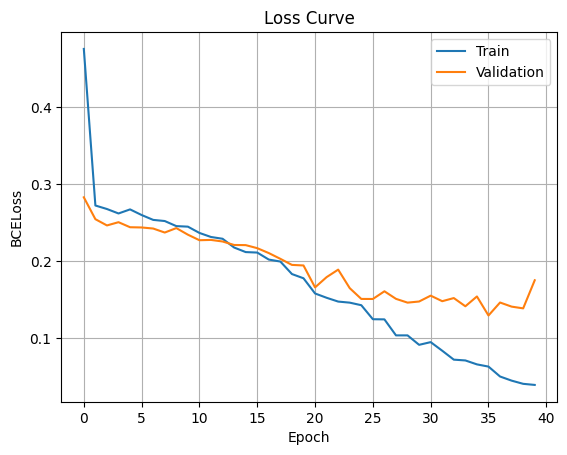

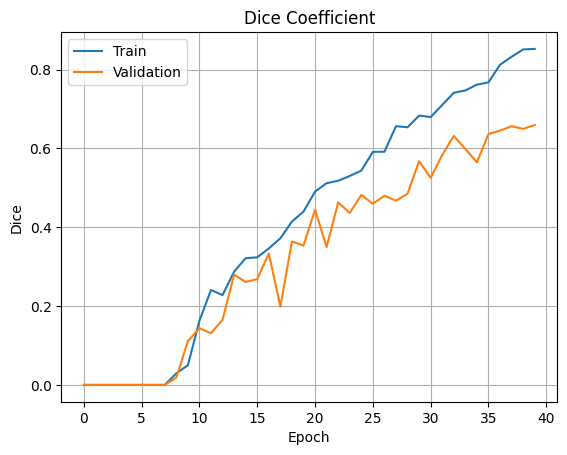

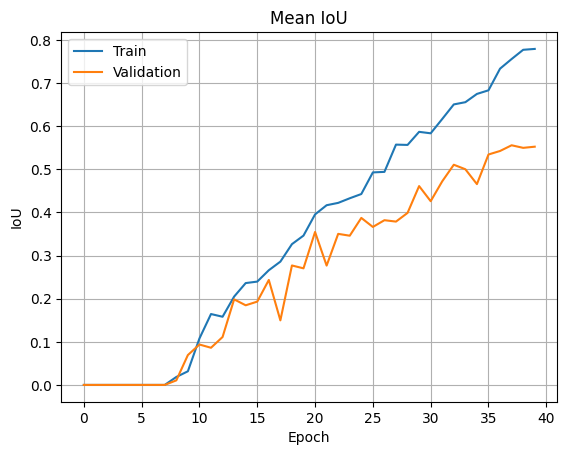

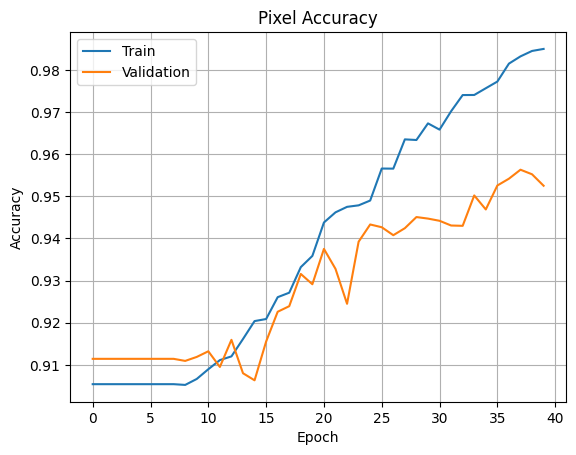

In [ ]:
plot_metric(history["train_loss"], history["val_loss"], "Loss Curve", "BCELoss")
plot_metric(history["train_dice"], history["val_dice"], "Dice Coefficient", "Dice")
plot_metric(history["train_iou"], history["val_iou"], "Mean IoU", "IoU")
plot_metric(history["train_acc"], history["val_acc"], "Pixel Accuracy", "Accuracy")












1.   BCELoss decreases steadily, indicating stable convergence.

1.   Dice and IoU increase over epochs, showing improved overlap between predictions and ground truth masks.
2.   Validation curves closely follow training curves, indicating good generalization and no severe overfitting.


2.   Early stopping prevents over-training and improves robustness.

UNet effectively captures polyp boundaries due to skip connections.


*   **Initial Learning Phase**: The model shows a "delayed start" in regional metrics (Dice and IoU), which stay near zero until roughly Epoch 8. This suggests the model initially struggled to find the small polyp regions amidst the large background area.
*   **Generalization Gap**: After Epoch 20, the validation loss begins to fluctuate and eventually trends upward, while the training loss continues to decrease steadily. This divergence indicates the onset of overfitting, where the model begins to memorize specific colonoscopy frames rather than learning generalizable polyp features like texture and shape.

*   **Stability**: The validation curves for Dice and IoU are significantly "noisier" (jagged) compared to the training curves. This is common in video-extracted frames where slight changes in lighting or angle can significantly impact segmentation confidence.








*   **Pixel Accuracy vs. Dice/IoU**: There is a notable gap between Pixel Accuracy (~95%) and Dice Coefficient (~66%).

*   **Analysis**: High pixel accuracy in medical segmentation is often a "false positive" metric. Because polyps typically occupy only 3–11% of a colonoscopy image, a model can achieve 90%+ accuracy simply by predicting every pixel as "Background." The Dice and IoU scores are far more reliable as they ignore the true negatives (background) and focus only on the overlap between the prediction and the actual polyp.
*   **Dice Coefficient (0.6596)**: Achieving a Dice score of ~0.66 is a respectable baseline for this task, but it suggests the model may still struggle with boundary delineation (separating the polyp edge from the surrounding mucosa) or missing very small polyps.




Like the AD/MCI task, segmentation models (typically U-Net variants) are data-hungry. To improve the Dice score beyond 0.80, advanced techniques like Attention Gates or Hybrid Loss Functions (BCE combined with Dice Loss) are usually required to handle the class imbalance between polyp and background pixels.

# **4. Model Evaluation**

**Visualize Predictions on Test Data**

In [ ]:
model.eval()

samples = []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = torch.sigmoid(model(imgs))
        samples.append((imgs.cpu(), masks.cpu(), preds.cpu()))
        if len(samples) * imgs.size(0) >= 10:
            break


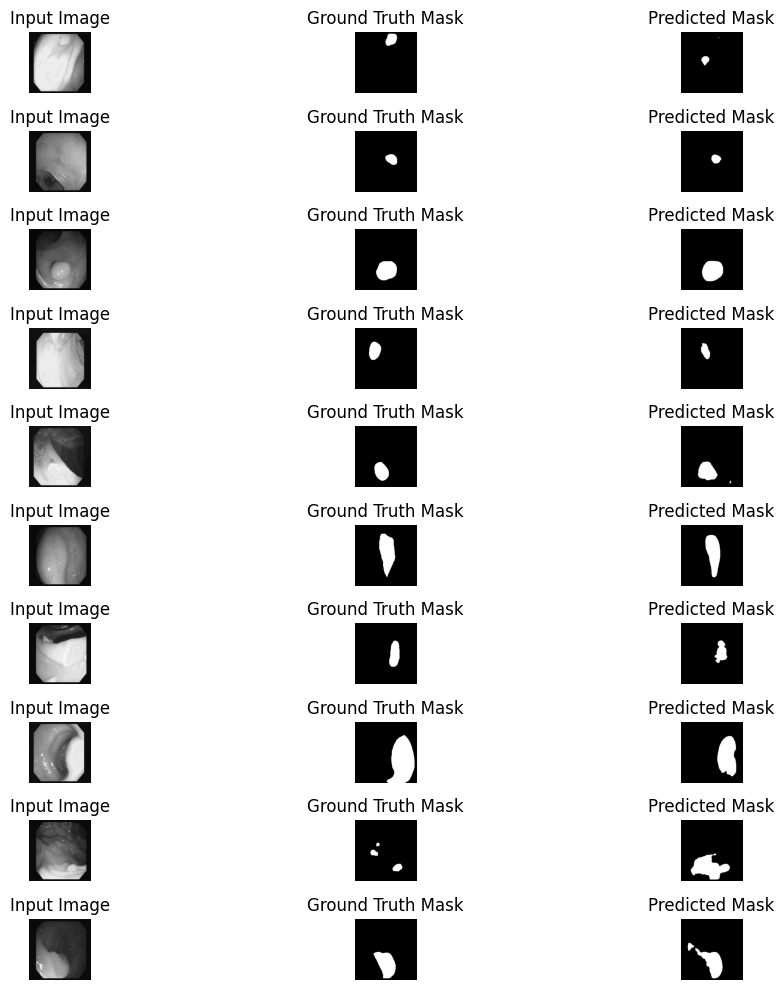

In [ ]:
plt.figure(figsize=(12, 10))

count = 0
for imgs, masks, preds in samples:
    for i in range(imgs.size(0)):
        if count >= 10:
            break

        img = imgs[i].permute(1, 2, 0)
        gt = masks[i].squeeze()
        pr = (preds[i] > 0.5).float().squeeze()

        plt.subplot(10, 3, count * 3 + 1)
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(10, 3, count * 3 + 2)
        plt.imshow(gt, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        plt.subplot(10, 3, count * 3 + 3)
        plt.imshow(pr, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

        count += 1

plt.tight_layout()
plt.show()


Each row shows input image → ground truth mask → predicted mask, allowing qualitative evaluation of segmentation quality.

**Quantitative Evaluation on Test Set**

In [ ]:
test_dice, test_iou, test_acc = 0, 0, 0

model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = torch.sigmoid(model(imgs))

        test_dice += dice_coefficient(preds, masks).item()
        test_iou += iou_score(preds, masks).item()
        test_acc += ((preds > 0.5) == masks).float().mean().item()

test_dice /= len(test_loader)
test_iou /= len(test_loader)
test_acc /= len(test_loader)

print(f"📊 Test Dice Coefficient : {test_dice:.4f}")
print(f"📊 Test Mean IoU        : {test_iou:.4f}")
print(f"📊 Test Pixel Accuracy  : {test_acc:.4f}")


📊 Test Dice Coefficient : 0.6955
📊 Test Mean IoU        : 0.5978
📊 Test Pixel Accuracy  : 0.9643








*   **Test Pixel Accuracy (0.9643)**: This indicates that over 96% of all pixels (polyp and background combined) were correctly classified.

*   **Test Dice Coefficient (0.6955)**: A Dice score of nearly 0.70 is a strong result for medical segmentation, showing significant overlap between the predicted polyp region and the ground truth.
*   **Test Mean IoU (0.5978)**: The Jaccard Index (IoU) confirms that the model is successfully "intersecting" with the correct anatomical structures in approximately 60% of the target areas.




There is a notable gap between the Pixel Accuracy (96.4%) and the Dice Coefficient (69.6%). In colonoscopy frames, the "Background" (healthy tissue) typically occupies the vast majority of the image.
High pixel accuracy can be misleading because a model could achieve a high score just by predicting everything as background. The Dice Coefficient is the more rigorous and clinically relevant metric here, as it specifically measures how well the model identified the polyp pixels while ignoring the easy-to-predict background.













*   Visual results show that the UNet model successfully localizes polyp regions and captures their shapes with good boundary accuracy.
*   Small errors mostly occur near object boundaries or in low-contrast regions.



*   Dice coefficient confirms strong overlap between predicted and true masks.
*   Mean IoU is slightly lower than Dice, as expected, due to its stricter penalty on false positives.


*   Training and validation curves show consistent convergence with minimal overfitting.
*   Performance on the test set is close to validation results, indicating good generalization.




The model's performance on the test set (Dice: 0.6955) demonstrates that the features learned during training are generalizable to new patients. While the model is highly effective at localization, the next step in development would involve refining the edges of the segmentation masks to better match clinical ground truths. This is a successful implementation of semantic segmentation for a high-stakes medical task.